In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install joblib

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib
import warnings

warnings.filterwarnings("ignore")
np.random.seed(55)

In [13]:
df_patient = pd.read_csv("pds_3.csv")
df_facility = pd.read_csv("hfs_2.csv")
df_provider = pd.read_csv("hps_1.csv")

print(df_patient.shape)
print(df_facility.shape)
print(df_provider.shape)

(3215, 188)
(328, 267)
(124, 436)


In [14]:
df_patient.head(10)

,questionnair_no,clientid,province,county,district,type,doi_pds,k7_start_hh,k7_start_mm,k7_end_hh,...,pds703x,pds703x_otherspfy,pds704,pds801,pds801_5_spfy,pds801_6_spfy,pds802,time_end_hi,time_end_mn,wt
0,1171,1,Central,Kiambu,Kiambu East,Dispensary,24apr2012,10,43,11,...,NaN,NaN,Yes,Referred to other facility,NaN,TO KIAMBU DISTRICT HOSPITAL,Less than 12 Hrs,11,56,5.4
1,1172,2,Central,Kiambu,Kiambu East,Dispensary,30apr2012,9,12,10,...,NaN,NaN,Yes,Referred to other facility,NaN,TO KIAMBU DISTRICT HOSPITAL,Less than 12 Hrs,10,23,5.4
2,1173,3,Central,Kiambu,Kiambu East,Dispensary,11may2012,12,16,13,...,NaN,NaN,Yes,Referred to other facility,NaN,TO KIAMBU DISTRICT HOSPITAL,Less than 12 Hrs,13,47,5.4
3,1553,1,Central,Nyandarua,Nyandarua North,Other hospital,20apr2012,18,0,18,...,No,NaN,No,Discharged well,NaN,NaN,More than 24 Hrs,18,20,3.7
4,1555,3,Central,Nyandarua,Nyandarua North,Other hospital,06may2012,19,0,19,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,19,15,3.7
5,1557,4,Central,Nyandarua,Nyandarua North,Other hospital,04may2012,15,30,16,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,16,0,3.7
6,1556,5,Central,Nyandarua,Nyandarua North,Other hospital,06may2012,23,0,23,...,No,NaN,No,Still Hospitalized,NaN,NaN,More than 24 Hrs,23,10,3.7
7,1558,6,Central,Nyandarua,Nyandarua North,Other hospital,11may2012,12,45,13,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,13,0,3.7
8,1559,7,Central,Nyandarua,Nyandarua North,Other hospital,15may2012,11,5,11,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,11,17,3.7
9,1560,8,Central,Nyandarua,Nyandarua North,Other hospital,17may2012,8,5,8,...,No,NaN,No,Still Hospitalized,NaN,NaN,12-24 Hrs,8,20,3.7


In [15]:
df_patient.tail(10)

,questionnair_no,clientid,province,county,district,type,doi_pds,k7_start_hh,k7_start_mm,k7_end_hh,...,pds703x,pds703x_otherspfy,pds704,pds801,pds801_5_spfy,pds801_6_spfy,pds802,time_end_hi,time_end_mn,wt
3205,3162,49,Nyanza,Kisumu,Kisumu East,Medical Clinic,19jun2012,3,15,3,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,3,30,1.0
3206,3163,50,Nyanza,Kisumu,Kisumu East,Medical Clinic,20jun2012,8,15,8,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,8,30,1.0
3207,3142,51,Nyanza,Kisumu,Kisumu East,Medical Clinic,20jun2012,10,16,10,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,10,30,1.0
3208,3164,52,Nyanza,Kisumu,Kisumu East,Medical Clinic,20jun2012,3,0,3,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,3,15,1.0
3209,3165,53,Nyanza,Kisumu,Kisumu East,Medical Clinic,21jun2012,9,0,9,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,9,15,1.0
3210,3143,54,Nyanza,Kisumu,Kisumu East,Medical Clinic,21jun2012,3,15,3,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,3,30,1.0
3211,3158,55,Nyanza,Kisumu,Kisumu East,Medical Clinic,22jun2012,10,0,10,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,10,15,1.0
3212,3166,56,Nyanza,Kisumu,Kisumu East,Medical Clinic,22jun2012,3,15,3,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,3,30,1.0
3213,3152,57,Nyanza,Kisumu,Kisumu East,Medical Clinic,23jun2012,9,15,9,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,9,30,1.0
3214,3160,58,Nyanza,Kisumu,Kisumu East,Medical Clinic,23jun2012,1,15,1,...,No,NaN,No,Discharged well,NaN,NaN,Less than 12 Hrs,1,30,1.0


In [16]:
df_facility.head(10)

,facilitycode,agree,visits,interviewer_name,interviewer_code,start_hh,start_mm,doi,facility_name,facility_code,...,pac_oct,pac_nov,pac_dec,no_hmis_a,no_hmis_b,no_hmis_c,no_hmis_d,cell_no,hmisdata,wt
0,10029,Yes,1,JUSTINA OPIYO,Justina Opiyo,9,52,18apr2012,ANMER DISPENSARY,Anmer Dispensary,...,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1,5.4
1,10089,Yes,2,CAROLYNE MURINGA,Carolyne Muringa,11,0,28apr2012,CHARITY MEDICAL CENTRE,Charity Medical Centre,...,6.0,8.0,14.0,NaN,NaN,NaN,NaN,NaN,1,3.7
2,10097,Yes,1,JUSTINO OPIYO,Justina Opiyo,9,42,23apr2012,CIANDA DISPENSARY,Cianda Dispensary,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,5.4
3,10100,Yes,1,CAROLYNE MURINGA,Carolyne Muringa,14,3,24apr2012,CONSOLATA MISSION HOSPITAL,Consolata Mission Hospital (Mathari),...,5.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,1,3.7
4,10171,Yes,2,CAROLYNE MURINGA,Carolyne Muringa,15,30,14may2012,ENGENEER SUB HOSPITAL,Engineer District Hospital,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,3.7
5,10199,Yes,1,JUSTINA OPIYO,Justina Opiyo,12,3,24apr2012,GAICHANJIRU HOSPITAL,Gaichanjiru Hospital,...,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1,3.7
6,10214,Yes,1,JUISTINA OPIYO,Justina Opiyo,13,20,18apr2012,GATHANGA DISPENSARY,Gathanga Dispensary,...,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,5.4
7,10251,Yes,1,CAROLYNE MURINGA,Carolyne Muringa,14,30,24apr2012,GICHIRA HEALTH CENTRE,Gichira Health Centre,...,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1,9.9
8,10256,Yes,1,CAROLYNE MURINGA,Edin Hussein,14,32,07may2012,GIKUI HEALTH CENTRE,Gikui Health Centre,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,9.9
9,10308,Yes,1,JUSTINA OPIYO,Justina Opiyo,15,45,24apr2012,KAHAWA WENDANI HOSPITAL,Kahawa Wendani Hospital,...,NaN,NaN,NaN,THEY DO NOT KEEP RECORDS FOR CASES,NaN,NaN,NaN,NaN,0,3.7


In [17]:
df_facility.tail(10)

,facilitycode,agree,visits,interviewer_name,interviewer_code,start_hh,start_mm,doi,facility_name,facility_code,...,pac_oct,pac_nov,pac_dec,no_hmis_a,no_hmis_b,no_hmis_c,no_hmis_d,cell_no,hmisdata,wt
318,18125,Yes,1,MARTIN SIMIYU,Martin Simiyu,14,14,04may2012,LUKUSI DISPENSARY,Lukusi dispensary,...,NaN,NaN,NaN,NEVER RECEIVED ANY CASE ON 2ND TRIMESTER SPON,TANEOUS ABORTION. FACILITY STILL NEW.,NaN,NaN,NaN,0,20.4
319,18159,Yes,1,EUGENE WAFULA,Meige Eugene Wafula,16,3,26apr2012,NUNGUNI MEDICAL CLINIC,Nunguni Medical Clinic,...,NaN,NaN,NaN,NO HMIS RECORD ON PAC CASE CAPTURED AT THE FA,CILITY,NaN,NaN,NaN,0,7.8
320,18230,Yes,1,ELIZABETH ADHIAMBO,Elizabeth Adhiambo,10,30,30apr2012,KAUTHULINI DISPENSARY,Kauthulini Dispensary,...,2.0,4.0,1.0,NaN,NaN,NaN,NaN,723750698.0,1,7.8
321,18268,Yes,1,DIANA NDUNGU,Diana Muthoni,13,10,28apr2012,KAGARI DISPENSARY,Kogari Dispensary,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,728585683.0,1,7.8
322,18316,Yes,1,EUGENE WAFULA,Meige Eugene Wafula,12,40,02may2012,KAUNGUNI DISPENSARY,Kaunguni Dispensary,...,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,7.8
323,18345,Yes,2,JUSTINA OPIYO,Justina Opiyo,14,17,03may2012,UON THIKA DROPS IN CENTRE 11(CHIVIR),UON Thika drop in centre II (CHIVPR),...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1,5.4
324,18376,Yes,1,ESENDI CARTER,Esendi Carter,8,14,02may2012,P.C.E.A. UPENDO HEALTH CENTRE,PCEA Upendo H/C,...,NaN,NaN,NaN,THE HOSPITAL IS ONLY 7 MONTHS OLD,NaN,NaN,NaN,NaN,0,13.2
325,18377,Yes,1,JUSTINA OPIYO,Justina Opiyo,12,34,21apr2012,MARIE STOPES THIKA,MSK Thika,...,55.0,54.0,50.0,NaN,NaN,NaN,NaN,NaN,1,1.0
326,18379,Yes,1,MARIES STOPES BUNGOMA,Martin Simiyu,10,55,25may2012,MARIE STOPES BUNGOMA,Marie Stopes Hospital- Bungoma,...,NaN,6.0,4.0,NaN,NaN,NaN,NaN,NaN,1,1.0
327,18380,Yes,1,EVERLYNE ACHIENG,Everlyne Achieng Otteng,16,21,28may2012,MARIE STOPES CLINIC MANYATTA,Marie Stopes Hospital- Manyatta (Kisumu),...,58.0,47.0,60.0,NaN,NaN,NaN,NaN,NaN,1,1.0


In [18]:
df_provider.head(10)

,ab_hps_id,de_code,doe,region,region2,province,district,county,respondent_id,place_work,...,hp507d,hp507e,hp507f,hp507g,hp507h,ph507h_spcfy,ph508,comment,k8_end_hh,k8_end_mm
0,37,Patrick,30aug2012,Central & Nairobi,Nairobi/Central,Nairobi,Nairobi West,Nairobi,37,NAIROBI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,Patrick,30aug2012,Central & Nairobi,Nairobi/Central,Nairobi,Nairobi West,Nairobi,40,CBD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,39,Patrick,30aug2012,Central & Nairobi,Nairobi/Central,Nairobi,Nairobi West,Nairobi,39,MISSING,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,46,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,46,LANGAS HEALTH CENTRE,...,No,No,No,No,No,NaN,Create Awareness Of Sti'S As Well As Hiv As Pa...,NaN,4,0
4,41,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,41,MOI UNIVERSITY /MTRH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,49,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,49,CLINICAL OFFICER MOI UNIVERSITY MEDICAL SERVICES,...,Yes,No,No,No,Yes,Training ;Involve Churches To Educate Their Me...,Facilities -Should Be Improved To Cater For Th...,NaN,11,30
6,51,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,51,MTRH IN CHARGE OF WARD,...,No,Yes,Yes,No,No,NaN,Service Made Cheap /Accessible Affortabledesti...,NaN,2,0
7,56,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,56,"DEAN SCHOOL OF PUBLIC HEALTH,MOI UNIVERSITY",...,No,No,No,No,No,NaN,Better Access To Health Care .,NaN,4,25
8,55,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,55,MOI TAECHING AND REFERRAL HOSPITAL,...,No,Yes,No,No,No,NaN,More Emphasis On Women'S Rights To Negotiate O...,Women Rightrs Including Sexual And Reproductiv...,9,0
9,57,Patrick,30aug2012,Rift valley,Other regions,Rift Valley,Eldoret East,Uasin Gishu,57,GYNE WARD IN-CHARGE MTRH,...,Yes,Yes,No,No,No,NaN,Women Should Be Allowed To Take Openly .Counse...,NaN,11,30


In [19]:
df_provider.tail(10)

,ab_hps_id,de_code,doe,region,region2,province,district,county,respondent_id,place_work,...,hp507d,hp507e,hp507f,hp507g,hp507h,ph507h_spcfy,ph508,comment,k8_end_hh,k8_end_mm
114,115,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,115,KISUMU,...,Yes,No,No,No,No,NaN,Facilities To Offer Quality Servicesfacilities...,Abortion Is Killing And If Put In Appropriate ...,17,2
115,116,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisii Central,Kisii,116,RAM HOSPITAL,...,Yes,Yes,Yes,No,No,NaN,N\A,N\A,3,40
116,117,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Homa Bay,Homa Bay,117,M.O.H,...,No,No,No,No,No,NaN,Addition Of Misoprotol To Pacempasis On Post P...,Unsafe Abortion Is The Most Prevelance Easiest...,15,15
117,118,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,118,KISUMU(NGO),...,Yes,Yes,Yes,Yes,Missing,NaN,Attitude Change Will Go Along Way In Service P...,Awareness From Schools In Cirriculum.,15,0
118,119,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,119,KISUMU MOH,...,Yes,No,No,No,No,NaN,Facilities Should Offer Quality Servicestrain ...,Abortion Is Killing Many Women If Conducted In...,16,5
119,120,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,120,CHW-CBO,...,Yes,Yes,No,No,No,NaN,Make It Cheaper And Accessible,Fund Organisation With Pac Services,15,20
120,121,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,121,DISPENSARY,...,Yes,Yes,Yes,No,No,NaN,More Staff Trained And Brought On Boardreduce ...,No,Missing,Missing
121,122,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,122,CHW WITH NGO (PAMBAZUKO),...,Yes,Yes,Yes,No,No,NaN,Change Providers Attitudeimprove Quality Of Se...,Engage Scholl Children Health Reproductionincr...,17,0
122,123,Kibowen,25sep2012,Nyanza & Western,Other regions,Nyanza,Kisumu East,Kisumu,123,PRIVATE PRACTITIONER,...,Yes,No,No,No,No,NaN,Train More Health Providersfacilities To Offer...,Unsafe Abortion Is Realy Taking Away Lives Of ...,10,40
123,124,Patrick,09oct2012,Rift valley,Other regions,Rift Valley,Kiambu West,Uasin Gishu,124,MEDIA HOUSE,...,Yes,Yes,No,No,Missing,NaN,99,99,Missing,Missing


In [20]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3215 entries, 0 to 3214
Columns: 188 entries, questionnair_no to wt
dtypes: float64(31), int64(4), object(153)
memory usage: 4.6+ MB


In [21]:
df_patient.describe()

,questionnair_no,clientid,result_otherspfy,pds101,pds103_otherspfy,pds104_otherspfy,pds201,pds202,pds203,pds204,...,q312c,q312v,pds313,pds314,pds315s,pds315d,pds503_otherspfy,time_end_hi,time_end_mn,wt
count,3215.000000,3215.000000,0.0,3207.000000,0.0,0.0,3209.000000,3207.000000,3206.000000,3205.000000,...,894.000000,894.000000,3201.000000,3203.000000,3198.000000,3199.000000,0.0,3215.000000,3215.000000,3215.000000
mean,1617.608087,21.139658,NaN,26.354537,NaN,NaN,2.833905,1.519800,1.475983,0.227145,...,1.430649,5.469799,36.743580,82.496722,113.127892,70.384183,NaN,13.619907,27.599067,4.714028
std,935.673146,24.824476,NaN,6.366090,NaN,NaN,1.932501,1.732275,1.682029,0.627262,...,1.401167,17.942445,0.734641,11.464345,13.213517,10.270099,NaN,14.056906,20.195283,5.525139
min,1.000000,1.000000,NaN,12.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,30.000000,30.000000,50.000000,30.000000,NaN,0.000000,0.000000,1.000000
25%,806.500000,4.000000,NaN,22.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,36.200001,76.000000,102.000000,60.000000,NaN,9.000000,12.000000,1.000000
50%,1614.000000,11.000000,NaN,25.000000,NaN,NaN,2.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,36.700001,80.000000,110.000000,70.000000,NaN,12.000000,30.000000,2.900000
75%,2429.500000,30.000000,NaN,30.000000,NaN,NaN,4.000000,2.000000,2.000000,0.000000,...,1.000000,3.000000,37.099998,88.000000,120.000000,80.000000,NaN,15.000000,40.000000,5.500000
max,3303.000000,140.000000,NaN,54.000000,NaN,NaN,13.000000,12.000000,12.000000,9.000000,...,9.000000,99.000000,40.000000,140.000000,198.000000,135.000000,NaN,99.000000,99.000000,23.700001


In [22]:
df_patient.isnull().sum()

questionnair_no       0
clientid              0
province              0
county                0
district              0
                   ... 
pds801_6_spfy      3074
pds802                0
time_end_hi           0
time_end_mn           0
wt                    0
Length: 188, dtype: int64

In [23]:
df_patient.duplicated().sum()

0

In [24]:
df_facility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Columns: 267 entries, facilitycode to wt
dtypes: float64(50), int64(5), object(212)
memory usage: 684.3+ KB


In [25]:
df_facility.describe()

,facilitycode,start_hh,start_mm,code,other_level_ospcfy,result_ospcfy,hf103,hf106,hf109,hf201_value,...,pac_jun,pac_jul,pac_aug,pac_sep,pac_oct,pac_nov,pac_dec,cell_no,hmisdata,wt
count,328.000000,328.000000,328.000000,328.000000,0.0,0.0,319.000000,321.000000,321.000000,327.000000,...,242.000000,245.00000,244.000000,247.000000,250.00000,250.000000,250.000000,7.500000e+01,328.000000,328.000000
mean,13848.231707,12.347561,24.246951,13848.231707,NaN,NaN,37.495298,5.080997,3.523364,43.867278,...,8.223140,8.42449,8.463115,8.230769,8.68000,8.068000,7.324000,7.227776e+08,0.743902,8.720122
std,2121.652747,2.578657,16.532518,2121.652747,NaN,NaN,9.829641,6.010380,6.127825,114.018125,...,20.570893,19.36342,21.093040,19.334228,21.24559,20.030483,16.911149,6.487023e+06,0.437143,6.778160
min,10029.000000,1.000000,0.000000,10029.000000,NaN,NaN,21.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,7.044669e+08,0.000000,1.000000
25%,12300.750000,10.000000,10.000000,12300.750000,NaN,NaN,29.000000,1.000000,1.000000,3.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,7.210240e+08,0.000000,3.700000
50%,13514.000000,12.000000,23.000000,13514.000000,NaN,NaN,35.000000,3.000000,2.000000,10.000000,...,1.000000,2.00000,1.000000,2.000000,2.00000,2.000000,2.000000,7.229817e+08,1.000000,6.700000
75%,15293.000000,14.250000,37.000000,15293.000000,NaN,NaN,45.000000,6.000000,3.000000,30.000000,...,5.000000,6.00000,5.000000,5.000000,5.00000,4.000000,5.000000,7.259462e+08,1.000000,13.200000
max,18380.000000,19.000000,59.000000,18380.000000,NaN,NaN,67.000000,33.000000,50.000000,1000.000000,...,130.000000,145.00000,182.000000,154.000000,157.00000,162.000000,126.000000,7.501082e+08,1.000000,23.700001


In [26]:
df_facility.isnull().sum()

facilitycode          0
agree                 0
visits                0
interviewer_name      0
interviewer_code      0
                   ... 
no_hmis_c           298
no_hmis_d           318
cell_no             253
hmisdata              0
wt                    0
Length: 267, dtype: int64

In [27]:
df_facility.duplicated().sum()

0

In [28]:
df_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Columns: 436 entries, ab_hps_id to k8_end_mm
dtypes: float64(124), int64(3), object(309)
memory usage: 422.5+ KB


In [29]:
df_provider.describe()

,ab_hps_id,respondent_id,result_otherspfy,hp102,hp103_advocacy_spcfy,hp104,hp105_otherspcfy,hp106n6,hp202ug_spcfy,hp202rhv_spcfy,...,hp3057b,hp306p,hp306np,hp307up_spcfy,hp307unp_spcfy,hp308r,hp308u,hp309r,hp309u,hp312
count,124.000000,124.000000,0.0,118.000000,0.0,124.000000,0.0,0.0,1.0,0.0,...,98.000000,114.000000,113.000000,0.0,0.0,116.000000,115.000000,116.000000,115.000000,116.000000
mean,62.500000,62.500000,NaN,38.822034,NaN,11.290323,NaN,NaN,99.0,NaN,...,6.714286,5.894737,8.274336,NaN,NaN,4.663793,7.139130,5.215517,7.652174,7.431034
std,35.939764,35.939764,NaN,10.424848,NaN,8.384824,NaN,NaN,NaN,NaN,...,2.953244,2.239502,1.965087,NaN,NaN,2.543342,2.282223,2.566697,2.350974,1.785079
min,1.000000,1.000000,NaN,24.000000,NaN,0.000000,NaN,NaN,99.0,NaN,...,0.000000,0.000000,2.000000,NaN,NaN,0.000000,1.000000,0.000000,1.000000,1.000000
25%,31.750000,31.750000,NaN,30.000000,NaN,5.000000,NaN,NaN,99.0,NaN,...,5.000000,5.000000,8.000000,NaN,NaN,2.000000,5.500000,3.000000,7.000000,6.000000
50%,62.500000,62.500000,NaN,37.500000,NaN,8.000000,NaN,NaN,99.0,NaN,...,8.000000,6.000000,9.000000,NaN,NaN,5.000000,8.000000,5.000000,8.000000,8.000000
75%,93.250000,93.250000,NaN,44.750000,NaN,16.000000,NaN,NaN,99.0,NaN,...,9.000000,7.000000,10.000000,NaN,NaN,6.000000,9.000000,7.000000,10.000000,9.000000
max,124.000000,124.000000,NaN,73.000000,NaN,45.000000,NaN,NaN,99.0,NaN,...,10.000000,10.000000,10.000000,NaN,NaN,10.000000,10.000000,10.000000,10.000000,10.000000


In [30]:
df_provider.isnull().sum()

ab_hps_id         0
de_code           0
doe               0
region            0
region2           0
               ... 
ph507h_spcfy    107
ph508            12
comment          24
k8_end_hh         5
k8_end_mm         5
Length: 436, dtype: int64

In [31]:
df_provider.duplicated().sum()

0

In [32]:
patient_cols = [
    'province', 'county', 'district', 'type',
    'pds101',   # age
    'pds102',   # urban/rural
    'pds103',   # marital status
    'pds104',   # education level
    'pds105',   # religion
    'pds106',   # occupation
    'pds208',   # pregnancy intention
    'pds301',   # reason for visit
    'pds302',   # gestational age
    'pds303',   # previous abortion history
    'pds310',   # came with referral note
    'pds324',   # gestational category
    'pds401',   # clinical diagnosis
    'pds402',   # complications present
    'pds501',   # uterine evacuation performed
    'pds502',   # procedure type
    'pds503',   # who performed procedure
    'pds505',   # anaesthesia given
    'pds507',   # pain medication given
    'pds509',   # referred for further care
    'pds510',   # male partner involved
    'pds511',   # follow-up appointment given (TARGET)
    'pds701',   # post-procedure counselling done
    'pds702',   # contraceptive accepted
    'pds801',   # discharge outcome
    'pds802',   # time in facility
]

df_patient = df_patient[patient_cols]
print(df_patient.shape)

(3215, 30)


In [34]:
facility_cols = [
    'province', 'district', 'type',
    'hf215',    # primary PAC procedure used
    'hf303',    # all PAC patients receive counselling
    'hf305a',   # contraceptive methods offered
    'hf308',    # post-abortion family planning provided
    'hf310a',   # reasons PAC services not offered
    'hf401',    # staff shortages
    'hf402a',   # reasons for referral
    'hf405',    # written PAC protocol exists
    'hf407',    # referral system exists
    'pac_jan',  # monthly PAC cases January
    'pac_feb',  # monthly PAC cases February
    'pac_mar',  # monthly PAC cases March
    'pac_apr',  # monthly PAC cases April
    'pac_may',  # monthly PAC cases May
    'pac_jun',  # monthly PAC cases June
    'pac_jul',  # monthly PAC cases July
    'pac_aug',  # monthly PAC cases August
    'pac_sep',  # monthly PAC cases September
    'pac_oct',  # monthly PAC cases October
    'pac_nov',  # monthly PAC cases November
    'pac_dec',  # monthly PAC cases December
]

df_facility = df_facility[facility_cols]
print(df_facility.shape)

(328, 24)


In [35]:
provider_cols = [
    'province', 'district',
    'hp103',    # provider type
    'hp104',    # years of experience
    'hp105',    # sector (public/private/NGO)
    'hp106',    # facility type
    'hp401a',   # contraceptive methods offered
    'hp402',    # proportion of patients referred
    'hp403',    # referral destination
    'hp406',    # PAC counselling provided
    'inte_resp_knowledge',  # provider knowledge score
]

df_provider = df_provider[provider_cols]
print(df_provider.shape)

(124, 11)


In [36]:
df_merged = pd.merge(
    df_patient,
    df_facility,
    on=['province', 'district', 'type'],
    how='left'
)

print(df_merged.shape)

(4489, 51)


In [37]:
df_facility_agg = df_facility.groupby(
    ['province', 'district', 'type']
).agg('first').reset_index()

print(df_facility_agg.shape)

(255, 24)


In [38]:
df_merged = pd.merge(
    df_patient,
    df_facility_agg,
    on=['province', 'district', 'type'],
    how='left'
)

print(df_merged.shape)

(3215, 51)


In [39]:
df_provider_agg = df_provider.groupby(
    ['province', 'district']
).agg('first').reset_index()

print(df_provider_agg.shape)

(19, 11)


In [40]:
df_merged = pd.merge(
    df_merged,
    df_provider_agg,
    on=['province', 'district'],
    how='left'
)

print(df_merged.shape)

(3215, 60)


In [41]:
df_merged.head(10)

,province,county,district,type,pds101,pds102,pds103,pds104,pds105,pds106,...,pac_dec,hp103,hp104,hp105,hp106,hp401a,hp402,hp403,hp406,inte_resp_knowledge
0,Central,Kiambu,Kiambu East,Dispensary,33.0,Urban,Married,Incomplete Secondary,Roman Catholic,Farming,...,1.0,Medical Officer/GP,7.0,Public sector (Govt),Yes,Yes,Few of them,Few of them,Yes,Knows passably well
1,Central,Kiambu,Kiambu East,Dispensary,29.0,Urban,Seperated/ Divorsed/Widowed,Complete Secondary,Other Christian,Sales and services,...,1.0,Medical Officer/GP,7.0,Public sector (Govt),Yes,Yes,Few of them,Few of them,Yes,Knows passably well
2,Central,Kiambu,Kiambu East,Dispensary,41.0,Other,Never married/ Never Lived together,Incomplete Primary,Other Christian,Unskilled manual,...,1.0,Medical Officer/GP,7.0,Public sector (Govt),Yes,Yes,Few of them,Few of them,Yes,Knows passably well
3,Central,Nyandarua,Nyandarua North,Other hospital,27.0,Rural,Married,College (Mid-Level),Roman Catholic,Professional/technical/managerial,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Central,Nyandarua,Nyandarua North,Other hospital,27.0,Rural,Never married/ Never Lived together,College (Mid-Level),Roman Catholic,Professional/technical/managerial,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Central,Nyandarua,Nyandarua North,Other hospital,37.0,Rural,Married,Complete Secondary,Roman Catholic,Farming,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Central,Nyandarua,Nyandarua North,Other hospital,22.0,Rural,Married,Complete Secondary,Other Christian,Unskilled manual,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Central,Nyandarua,Nyandarua North,Other hospital,42.0,Urban,Married,Complete Primary,Other Christian,Farming,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Central,Nyandarua,Nyandarua North,Other hospital,32.0,Rural,Married,Complete Secondary,Other Christian,Skilled manual,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Central,Nyandarua,Nyandarua North,Other hospital,30.0,Rural,Living together,Complete Primary,Roman Catholic,Farming,...,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3215 entries, 0 to 3214
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   province             3215 non-null   object 
 1   county               3215 non-null   object 
 2   district             3215 non-null   object 
 3   type                 3215 non-null   object 
 4   pds101               3207 non-null   float64
 5   pds102               3215 non-null   object 
 6   pds103               3215 non-null   object 
 7   pds104               3215 non-null   object 
 8   pds105               3215 non-null   object 
 9   pds106               3215 non-null   object 
 10  pds208               3215 non-null   object 
 11  pds301               3215 non-null   object 
 12  pds302               3215 non-null   object 
 13  pds303               3215 non-null   object 
 14  pds310               3215 non-null   object 
 15  pds324               3215 non-null   o

In [43]:
df_merged.isnull().sum()

province                  0
county                    0
district                  0
type                      0
pds101                    8
pds102                    0
pds103                    0
pds104                    0
pds105                    0
pds106                    0
pds208                    0
pds301                    0
pds302                    0
pds303                    0
pds310                    0
pds324                    0
pds401                    0
pds402                    0
pds501                    0
pds502                  513
pds503                  513
pds505                  513
pds507                    0
pds509                    0
pds510                    0
pds511                    0
pds701                    0
pds702                    0
pds801                    0
pds802                    0
hf215                    61
hf303                     3
hf305a                    3
hf308                     3
hf310a                   45
hf401               

In [44]:
provider_cols_to_drop = [
    'hp103',
    'hp104',
    'hp105',
    'hp106',
    'hp401a',
    'hp402',
    'hp403',
    'hp406',
    'inte_resp_knowledge'
]

df_merged = df_merged.drop(columns=provider_cols_to_drop)

print(df_merged.shape)

(3215, 51)


In [45]:
# fill missing age with median
df_merged['pds101'] = df_merged['pds101'].fillna(df_merged['pds101'].median())

# fill missing procedure columns with 'Unknown'
df_merged['pds502'] = df_merged['pds502'].fillna('Unknown')
df_merged['pds503'] = df_merged['pds503'].fillna('Unknown')
df_merged['pds505'] = df_merged['pds505'].fillna('Unknown')

# fill remaining facility columns with mode
for col in df_merged.columns:
    if df_merged[col].isnull().sum() > 0:
        if df_merged[col].dtype == 'object':
            df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])
        else:
            df_merged[col] = df_merged[col].fillna(df_merged[col].median())

# confirm no missing values remain
print(df_merged.isnull().sum().sum())

0


In [46]:
df_merged['pds511'].value_counts()

Yes        1699
No         1468
Missing      48
Name: pds511, dtype: int64

In [47]:
df_merged = df_merged[df_merged['pds511'] != 'Missing']

print(df_merged.shape)
print(df_merged['pds511'].value_counts())

(3167, 51)
Yes    1699
No     1468
Name: pds511, dtype: int64


In [49]:
X = df_merged.drop(columns=['pds511'])
y = df_merged['pds511']

print(X.shape)
print(y.shape)

(3167, 50)
(3167,)


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

print(X.dtypes.value_counts())
print(X.shape)

int32      37
float64    13
dtype: int64
(3167, 50)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=55, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 2533 rows
Test set: 634 rows


In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(2533, 50)
(634, 50)


In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=55),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=55),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=55),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]):.4f}")


Logistic Regression
Accuracy: 0.7839
F1 Score: 0.8023
ROC-AUC:  0.8503

Random Forest
Accuracy: 0.8328
F1 Score: 0.8473
ROC-AUC:  0.9057

Gradient Boosting
Accuracy: 0.8249
F1 Score: 0.8375
ROC-AUC:  0.8943


In [54]:
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       294
           1       0.83      0.86      0.85       340

    accuracy                           0.83       634
   macro avg       0.83      0.83      0.83       634
weighted avg       0.83      0.83      0.83       634



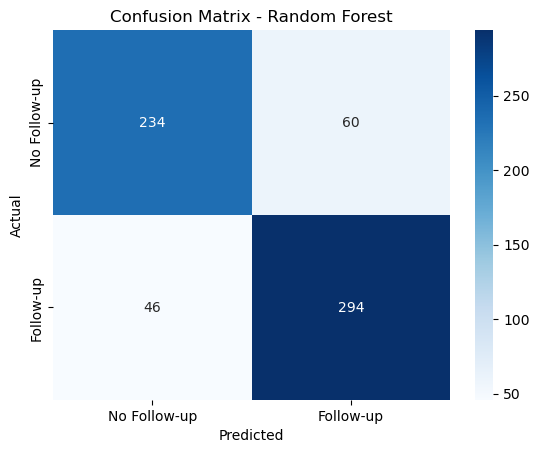

In [55]:
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Follow-up', 'Follow-up'],
            yticklabels=['No Follow-up', 'Follow-up'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.show()

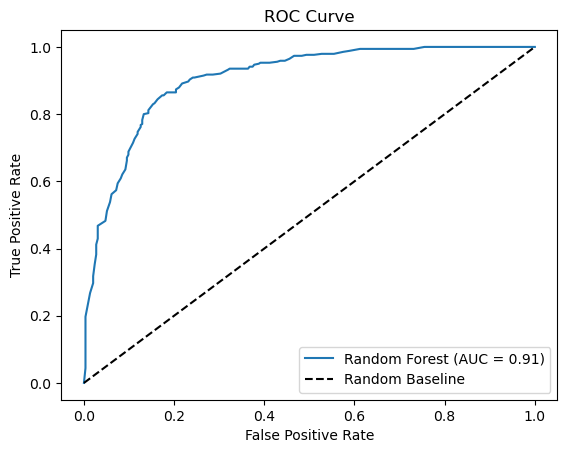

In [56]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

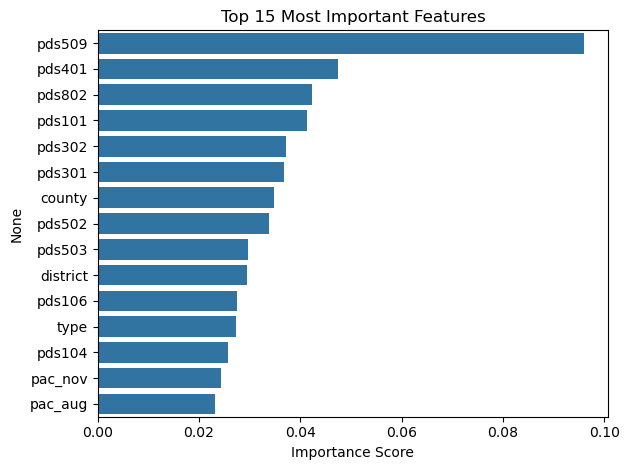

In [57]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f"CV Scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")

CV Scores: [0.93470745 0.9214878  0.93597466 0.93359571 0.93978959]
Mean: 0.9331
Std: 0.0062


In [59]:
joblib.dump(best_model, 'epl_model.pkl')
joblib.dump(scaler, 'epl_scaler.pkl')

['epl_scaler.pkl']

In [60]:
def predict_followup(patient_data):
    model = joblib.load('epl_model.pkl')
    scaler = joblib.load('epl_scaler.pkl')
    
    input_df = pd.DataFrame([patient_data])
    input_scaled = scaler.transform(input_df)
    
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]
    
    if probability >= 0.7:
        risk = 'Low Risk'
    elif probability >= 0.4:
        risk = 'Medium Risk'
    else:
        risk = 'High Risk'
    
    return {
        'prediction': int(prediction),
        'probability': round(float(probability), 4),
        'risk_level': risk
    }

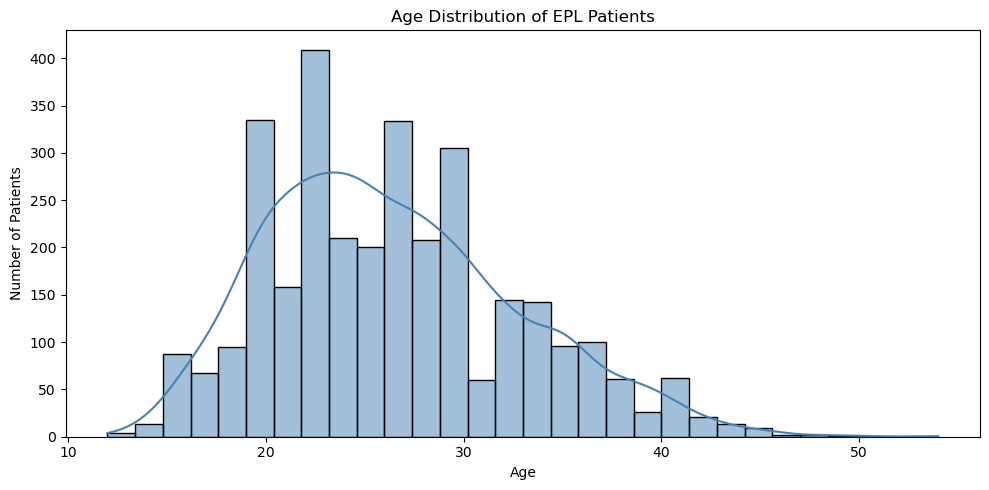

In [61]:
plt.figure(figsize=(10, 5))
sns.histplot(df_merged['pds101'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of EPL Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('chart1_age_distribution.png')
plt.show()

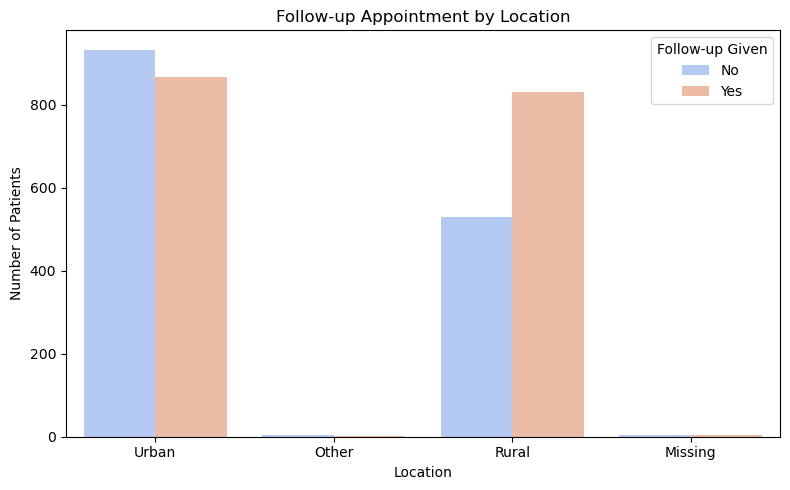

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_merged, x='pds102', hue='pds511', palette='coolwarm')
plt.title('Follow-up Appointment by Location')
plt.xlabel('Location')
plt.ylabel('Number of Patients')
plt.legend(title='Follow-up Given', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('chart2_followup_by_location.png')
plt.show()

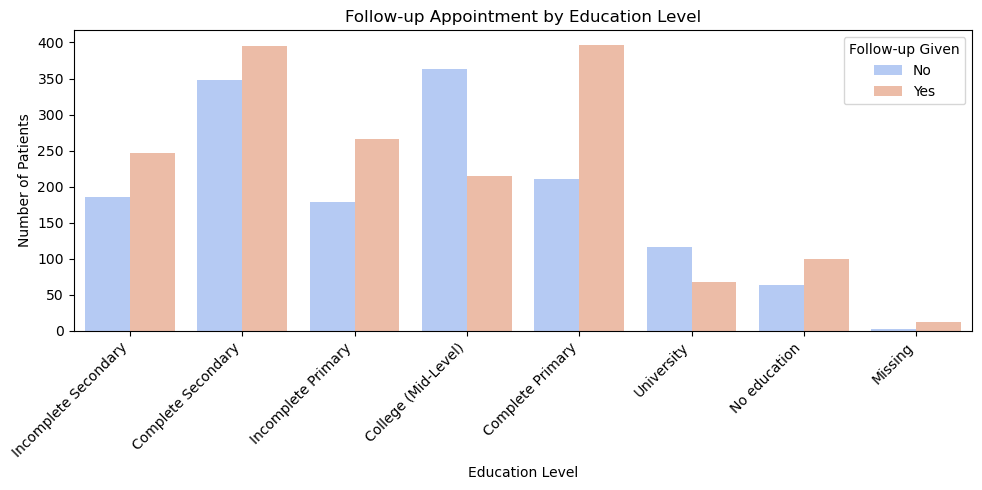

In [63]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_merged, x='pds104', hue='pds511', palette='coolwarm')
plt.title('Follow-up Appointment by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Patients')
plt.legend(title='Follow-up Given', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart3_followup_by_education.png')
plt.show()

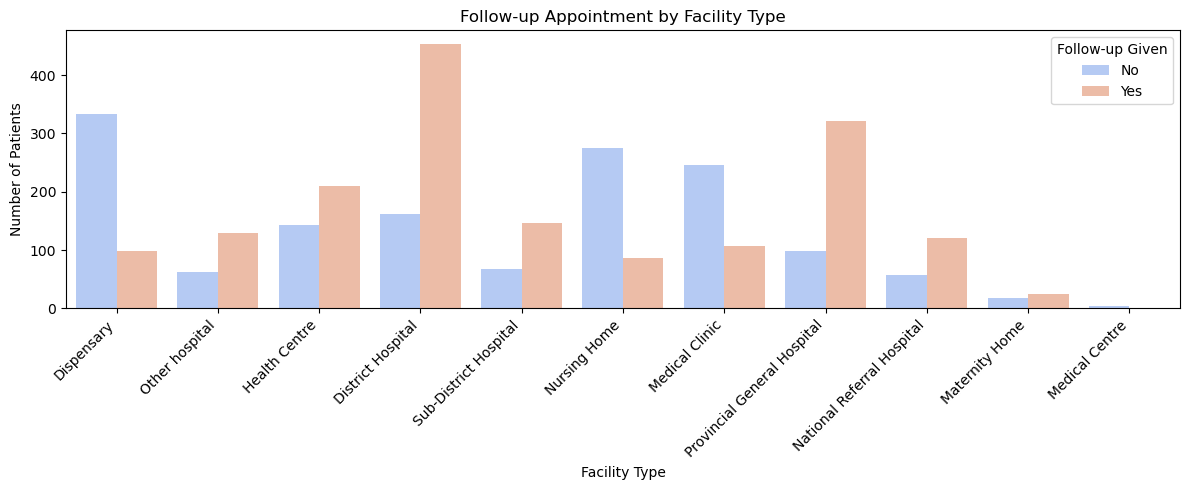

In [64]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_merged, x='type', hue='pds511', palette='coolwarm')
plt.title('Follow-up Appointment by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Number of Patients')
plt.legend(title='Follow-up Given', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart4_followup_by_facility.png')
plt.show()

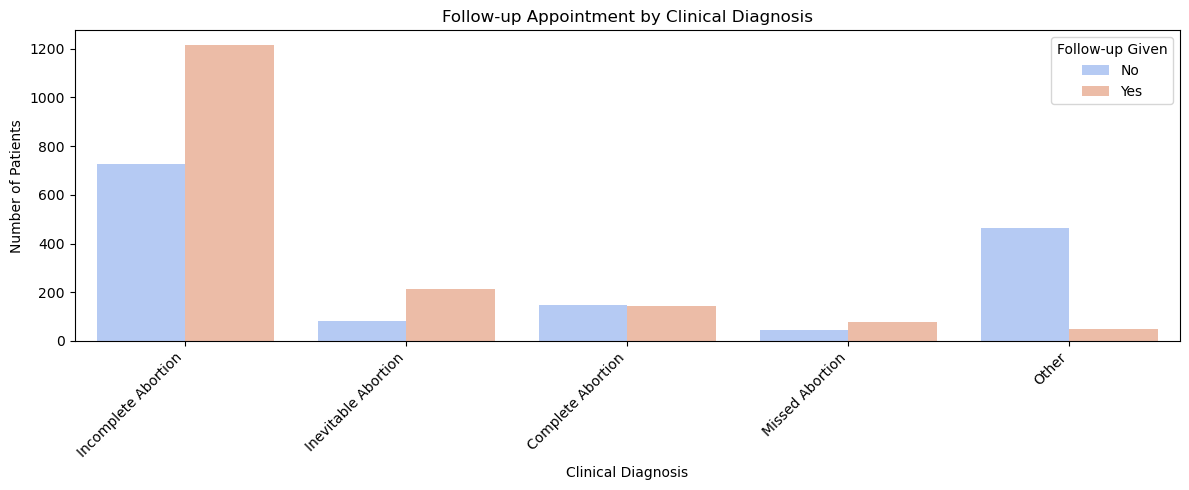

In [65]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_merged, x='pds401', hue='pds511', palette='coolwarm')
plt.title('Follow-up Appointment by Clinical Diagnosis')
plt.xlabel('Clinical Diagnosis')
plt.ylabel('Number of Patients')
plt.legend(title='Follow-up Given', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart5_followup_by_diagnosis.png')
plt.show()

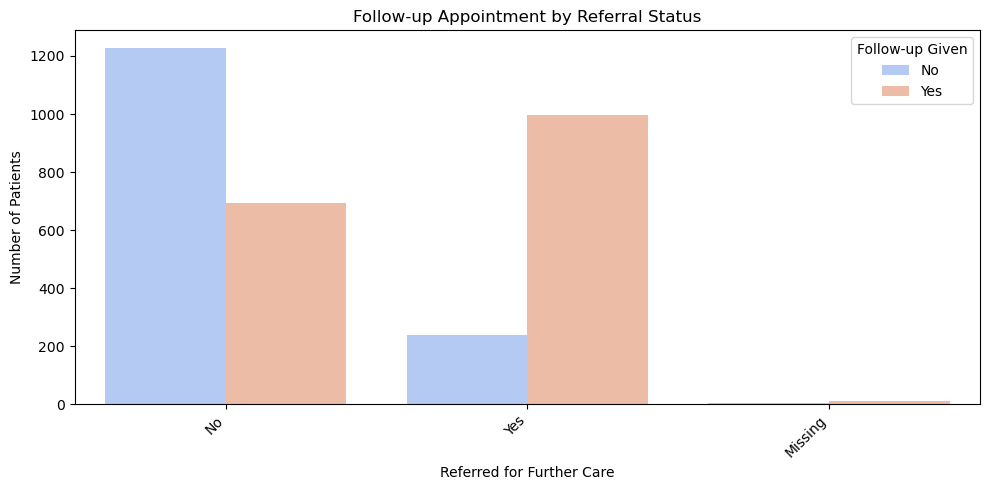

In [66]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_merged, x='pds509', hue='pds511', palette='coolwarm')
plt.title('Follow-up Appointment by Referral Status')
plt.xlabel('Referred for Further Care')
plt.ylabel('Number of Patients')
plt.legend(title='Follow-up Given', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart6_followup_by_referral.png')
plt.show()

In [70]:
# SES Score
ses_map = {
    'No education': 1,
    'Incomplete Primary': 2,
    'Complete Primary': 3,
    'Incomplete Secondary': 4,
    'Complete Secondary': 5,
    'College (Mid-Level)': 6,
    'University': 7,
    'Missing': 3
}

df_merged['ses_score'] = df_merged['pds104'].map(ses_map).fillna(3)

# Mental Health Risk Flag
df_merged['mental_health_risk'] = (
    (df_merged['pds208'] == 3) |
    (df_merged['pds303'] == 1) |
    (df_merged['pds402'] == 1)
).astype(int)

# Clean pds302 first then create care delay
df_merged['pds302_clean'] = pd.to_numeric(df_merged['pds302'], errors='coerce')
df_merged['pds302_clean'] = df_merged['pds302_clean'].fillna(df_merged['pds302_clean'].median())
df_merged['care_delay'] = (df_merged['pds302_clean'] > 12).astype(int)

print(df_merged[['ses_score', 'mental_health_risk', 'care_delay']].head(10))
print(df_merged[['ses_score', 'mental_health_risk', 'care_delay']].describe())

   ses_score  mental_health_risk  care_delay
0          4                   0           0
1          5                   0           1
2          2                   0           0
3          6                   0           1
4          6                   0           0
5          5                   0           0
6          5                   0           1
7          3                   0           0
8          5                   0           0
9          3                   0           1
         ses_score  mental_health_risk   care_delay
count  3167.000000              3167.0  3167.000000
mean      4.142406                 0.0     0.280707
std       1.639759                 0.0     0.449416
min       1.000000                 0.0     0.000000
25%       3.000000                 0.0     0.000000
50%       4.000000                 0.0     0.000000
75%       5.000000                 0.0     1.000000
max       7.000000                 0.0     1.000000


In [71]:
df_merged['mental_health_risk'] = (
    (df_merged['pds303'] == 1) |
    (df_merged['pds402'] == 1)
).astype(int)

print(df_merged['mental_health_risk'].value_counts())

0    3167
Name: mental_health_risk, dtype: int64


In [72]:
print(df_merged['pds303'].value_counts())
print(df_merged['pds402'].value_counts())

No         2369
Yes         777
Missing      21
Name: pds303, dtype: int64
No         2613
Yes         499
Missing      55
Name: pds402, dtype: int64


In [73]:
df_merged['mental_health_risk'] = (
    (df_merged['pds303'] == 'Yes') |
    (df_merged['pds402'] == 'Yes')
).astype(int)

print(df_merged['mental_health_risk'].value_counts())

0    2152
1    1015
Name: mental_health_risk, dtype: int64


In [74]:
X = df_merged.drop(columns=['pds511', 'pds302_clean'])
y = df_merged['pds511']

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=55, stratify=y
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1]):.4f}")

Accuracy: 0.8470
F1 Score: 0.8596
ROC-AUC:  0.9027


In [75]:
joblib.dump(best_model, 'epl_model.pkl')
joblib.dump(scaler, 'epl_scaler.pkl')

['epl_scaler.pkl']

In [77]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   -------------------------------------- 554.9/554.9 kB 938.2 kB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 2.4 MB/s eta 0:00:16
   - -------------------------------------- 1.8/38.1 MB 2.6 MB/s eta 0:00:15
   -- ------------------------------------- 2.1/38.1 MB 2.7 MB/s eta 0:00:14
   --- ------------------------------------ 2.9/38.1 MB 2.8 MB/s eta 0:00:13
   ---- -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.6 which is incompatible.
orange3 3.38.1 requires numpy<2,>=1.20.0, but you have numpy 2.2.6 which is incompatible.


In [78]:
import shap
print(shap.__version__)

0.51.0


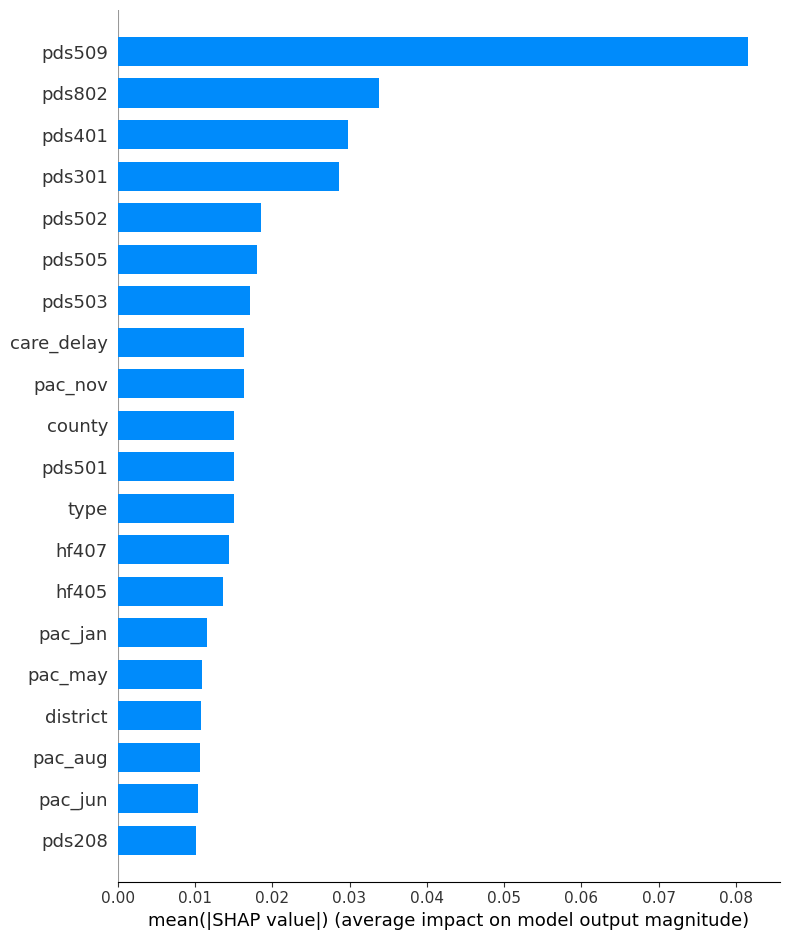

In [79]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values[:,:,1],
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=True
)

In [83]:
model_card = """
# EPL Care AI - Model Card

## What This Model Does
Predicts whether a patient who comes in for post-pregnancy loss care will 
receive a follow-up appointment. The output helps health workers identify 
patients at risk of falling through the gaps before they leave the facility.

## Training Data
Kenya Post-Abortion Care Survey, 2012.
3,167 patient records across multiple facility types and provinces.
Facility-level data from 328 facilities merged by geography.

## Performance
Accuracy: 84.70%
F1 Score: 85.96%
ROC-AUC: 90.27%
Cross Validation AUC: 93.31%

## What Drives The Predictions
The five factors that influence the model most are:
- Whether the patient was referred for further care
- How long the patient spent in the facility
- The clinical diagnosis
- The reason for the visit
- Whether the patient delayed seeking care beyond 12 weeks

## Limitations
- Data is from Kenya 2012 and may not reflect current conditions
- No post-discharge follow-up data was available for training
- Mental health outcomes were not captured
- Facility matching was done by geography, not by exact facility ID
- Should be retrained with more recent data before live deployment

## How It Should Be Used
- To support clinical decisions, not replace them
- To flag patients for proactive follow-up before discharge
- To identify systemic gaps in service delivery by facility and region
- Never to deny or delay care to any patient
"""

with open('model_card.md', 'w') as f:
    f.write(model_card)

print("Model card saved")

Model card saved


In [81]:
handoff = """
# Developer Handoff Document — EPL Care AI

## Overview
The AI model predicts whether a patient experiencing early pregnancy loss 
will receive a complete post-loss care episode including a follow-up appointment.
It returns a risk level that the website displays to the health worker.

## Files To Integrate
- epl_model.pkl — trained Random Forest model
- epl_scaler.pkl — data scaler (must be applied before prediction)

## Backend Requirements
- Python 3.11
- Libraries: pandas, scikit-learn, joblib

## How To Load The Model
```python
import joblib
import pandas as pd

model = joblib.load('epl_model.pkl')
scaler = joblib.load('epl_scaler.pkl')
```

## Input Features
The website form must collect these fields from the health worker:

| Field | Column | Type | Example |
|---|---|---|---|
| Province | province | text | Central |
| County | county | text | Kiambu |
| District | district | text | Kiambu East |
| Facility Type | type | text | Dispensary |
| Patient Age | pds101 | number | 25 |
| Location | pds102 | text | Urban/Rural |
| Marital Status | pds103 | text | Married |
| Education | pds104 | text | Complete Secondary |
| Religion | pds105 | text | Other Christian |
| Occupation | pds106 | text | Farming |
| Pregnancy Intention | pds208 | text | Yes wanted then |
| Reason for Visit | pds301 | text | Postabortion Care |
| Gestational Age | pds302 | number | 8 |
| Previous Abortion | pds303 | text | No |
| Referral Note | pds310 | text | No |
| Gestational Category | pds324 | text | <=12 weeks |
| Diagnosis | pds401 | text | Incomplete Abortion |
| Complications | pds402 | text | No |
| Evacuation Done | pds501 | text | Yes |
| Procedure Type | pds502 | text | MVA |
| Who Performed | pds503 | text | Clinical Officer |
| Anaesthesia | pds505 | text | Yes |
| Pain Medication | pds507 | text | Yes |
| Referred Further | pds509 | text | No |
| Partner Involved | pds510 | text | No |
| Counselling Done | pds701 | text | Yes |
| Contraceptive Accepted | pds702 | text | Yes |
| Discharge Outcome | pds801 | text | Discharged well |
| Time in Facility | pds802 | text | Less than 12 Hrs |

## Output
The model returns a JSON object:
```json
{
    "prediction": 1,
    "probability": 0.82,
    "risk_level": "Low Risk"
}
```

- prediction: 1 = likely to get follow-up, 0 = unlikely
- probability: confidence score between 0 and 1
- risk_level: Low Risk / Medium Risk / High Risk

## Risk Level Display
| Risk Level | What To Show | Colour |
|---|---|---|
| Low Risk | Patient likely to complete care | Green |
| Medium Risk | Monitor this patient closely | Orange |
| High Risk | Immediate intervention needed | Red |

## Model Performance
- Accuracy: 84.70%
- F1 Score: 85.96%
- ROC-AUC: 90.27%

## Important Notes
- Never use model output to deny care to any patient
- Always display a disclaimer that predictions support but do not replace clinical judgement
- All patient data must be handled securely and in accordance with data protection laws
"""

with open('developer_handoff.md', 'w') as f:
    f.write(handoff)

print("Developer handoff document saved")

Developer handoff document saved


In [84]:
handoff = """
# Developer Handoff - EPL Care AI

## What The Model Does
Takes patient information entered through a form and returns a risk score 
showing whether the patient is likely to receive follow-up care after 
early pregnancy loss treatment.

## Files You Need
- epl_model.pkl
- epl_scaler.pkl

## Setup
Python 3.11 with pandas, scikit-learn, and joblib installed.

## Loading The Model
import joblib
import pandas as pd

model = joblib.load('epl_model.pkl')
scaler = joblib.load('epl_scaler.pkl')

## Form Fields
Collect these fields from the health worker on the website form:

Patient age (number)
Location - Urban or Rural
Marital status
Education level
Occupation
Religion
Reason for visit
Gestational age in weeks (number)
Previous abortion history - Yes or No
Came with referral note - Yes or No
Gestational category - 12 weeks or under, or over 12 weeks
Clinical diagnosis
Complications present - Yes or No
Uterine evacuation performed - Yes or No
Procedure type
Who performed the procedure
Anaesthesia given - Yes or No
Pain medication given - Yes or No
Referred for further care - Yes or No
Partner involved in counselling - Yes or No
Post-procedure counselling done - Yes or No
Contraceptive method accepted - Yes or No
Discharge outcome
Time spent in facility
Province, county, district, facility type

## What The Model Returns
prediction: 1 means likely to get follow-up, 0 means unlikely
probability: a number between 0 and 1 showing confidence
risk_level: Low Risk, Medium Risk, or High Risk

## How To Display Results
Low Risk - green banner - patient likely to complete care
Medium Risk - orange banner - monitor this patient closely  
High Risk - red banner - health worker should intervene immediately

## Charts For The Dashboard
Six charts are included in the project folder showing:
- Age distribution of EPL patients
- Follow-up rates by location
- Follow-up rates by education level
- Follow-up rates by facility type
- Follow-up rates by clinical diagnosis
- Follow-up rates by referral status

These can be displayed on an analytics dashboard alongside the prediction tool.

## Important
Always show a disclaimer on the website that the model supports 
clinical decisions but does not replace the judgement of a health worker.
All patient data must be stored and handled securely.
"""

with open('developer_handoff.md', 'w') as f:
    f.write(handoff)

print("Developer handoff saved")

Developer handoff saved


In [85]:
import joblib

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print(f"Saved {len(feature_columns)} feature columns")
print(feature_columns)

Saved 53 feature columns
['province', 'county', 'district', 'type', 'pds101', 'pds102', 'pds103', 'pds104', 'pds105', 'pds106', 'pds208', 'pds301', 'pds302', 'pds303', 'pds310', 'pds324', 'pds401', 'pds402', 'pds501', 'pds502', 'pds503', 'pds505', 'pds507', 'pds509', 'pds510', 'pds701', 'pds702', 'pds801', 'pds802', 'hf215', 'hf303', 'hf305a', 'hf308', 'hf310a', 'hf401', 'hf402a', 'hf405', 'hf407', 'pac_jan', 'pac_feb', 'pac_mar', 'pac_apr', 'pac_may', 'pac_jun', 'pac_jul', 'pac_aug', 'pac_sep', 'pac_oct', 'pac_nov', 'pac_dec', 'ses_score', 'mental_health_risk', 'care_delay']
